In [1]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.arima_wrapper import AutoARIMAWrapper
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
DATA_DIR

'../data'

In [4]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [5]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [6]:
debug = False

In [7]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    model_params = {"sp":1, "d":None, "max_p":5, "max_q":5}
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    model = "arima"

        
    for symbol in crypto_symbols:

        forecaster = AutoARIMAWrapper(model_params)

        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")



        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print( f"test_history\n{test_history}")
            forecaster.fit(test_history)   
            try:
                point_forecast, _ = forecaster.forecast(forecasting_horizon=horizon)
                test_forecasts.extend(point_forecast)
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_{model}_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{model}_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_{model}_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{model}_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_{model}_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

aaa24560-68e0-4cb5-9938-84d942aaa58e
Model initialized: AutoARIMA
{'D': None, 'alpha': 0.05, 'concentrate_scale': False, 'd': None, 'enforce_invertibility': True, 'enforce_stationarity': True, 'error_action': 'warn', 'hamilton_representation': False, 'information_criterion': 'aic', 'max_D': 1, 'max_P': 2, 'max_Q': 2, 'max_d': 2, 'max_order': 5, 'max_p': 5, 'max_q': 5, 'maxiter': 50, 'measurement_error': False, 'method': 'lbfgs', 'mle_regression': True, 'n_fits': 10, 'n_jobs': 1, 'offset_test_args': None, 'out_of_sample_size': 0, 'random': False, 'random_state': None, 'scoring': 'mse', 'scoring_args': None, 'seasonal': True, 'seasonal_test': 'ocsb', 'seasonal_test_args': None, 'simple_differencing': False, 'sp': 1, 'start_P': 1, 'start_Q': 1, 'start_p': 2, 'start_params': None, 'start_q': 2, 'stationary': False, 'stepwise': True, 'suppress_warnings': True, 'test': 'kpss', 'time_varying_regression': False, 'trace': False, 'trend': None, 'update_pdq': True, 'with_intercept': True}
AutoARI

/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


...

/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.
Execution time for forecast_crypto_prices(): 335.5149962902069 seconds


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


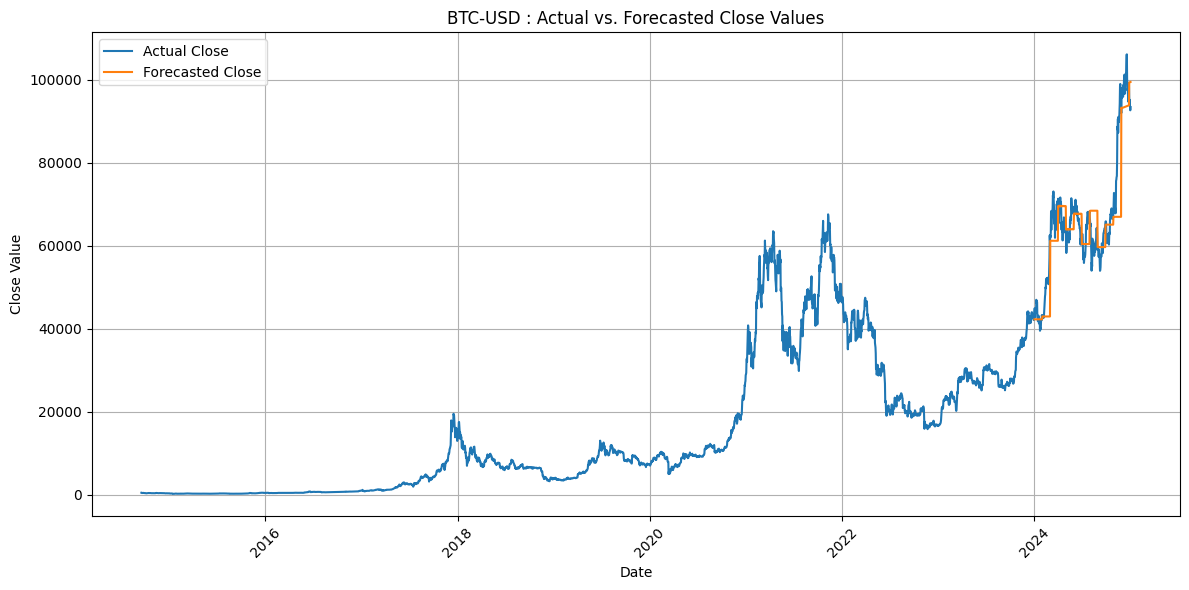

Evaluation Metric for BTC-USD_arima_30 Actual Values
MAPE: 7.509595301318706
ME: 1900.2412871556799
MAE: 5153.346346990704
MPE: 2.1652428825329246
RMSE: 7459.091089780902
R: 0.8713017272421595
Scalar Product: 1196626.9281415641
Return Score: 0.3041095890410959
Long Return: 0.3526315789473684
Short Return: 0.25142857142857145
Mean Directional Accuracy: 0.3041095890410959
Mean Directional Accuracy Positive: 0.3526315789473684
Mean Directional Accuracy Negative: 0.25142857142857145


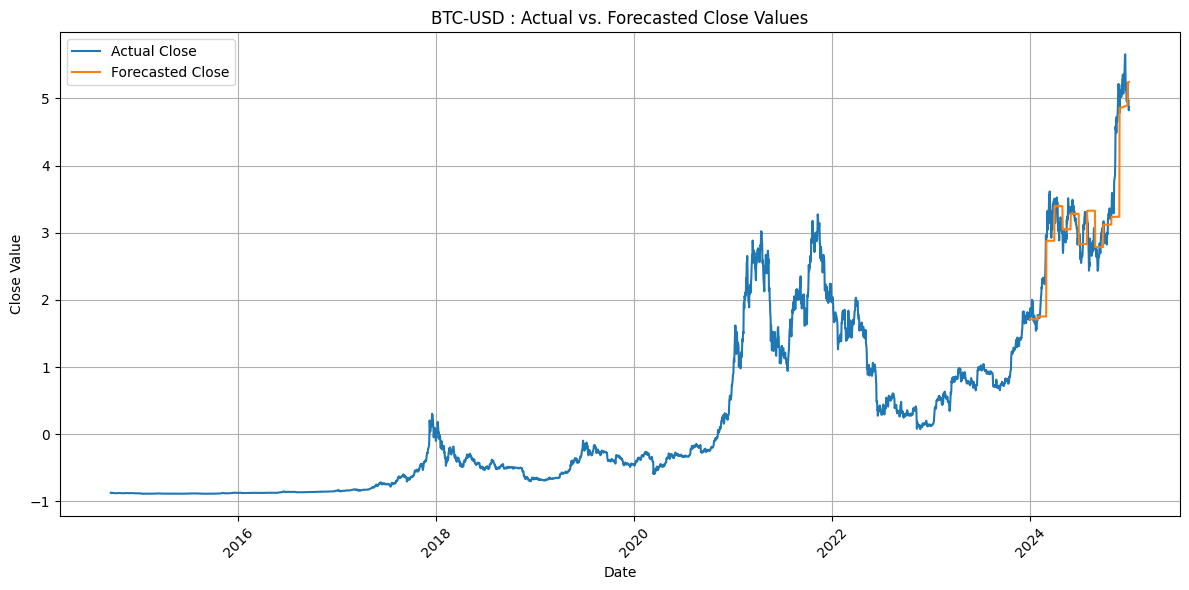

Evaluation Metric for BTC-USD_arima_30 Scaled
MAPE: 9.703198831796676
ME: 0.11739502748392273
MAE: 0.3183686409343776
MPE: 2.626636270009822
RMSE: 0.4608152708862662
R: 0.8713017272421593
Scalar Product: 0.0045671016262168185
Return Score: 0.3041095890410959
Long Return: 0.3526315789473684
Short Return: 0.25142857142857145
Mean Directional Accuracy: 0.3041095890410959
Mean Directional Accuracy Positive: 0.3526315789473684
Mean Directional Accuracy Negative: 0.25142857142857145
Model initialized: AutoARIMA
{'D': None, 'alpha': 0.05, 'concentrate_scale': False, 'd': None, 'enforce_invertibility': True, 'enforce_stationarity': True, 'error_action': 'warn', 'hamilton_representation': False, 'information_criterion': 'aic', 'max_D': 1, 'max_P': 2, 'max_Q': 2, 'max_d': 2, 'max_order': 5, 'max_p': 5, 'max_q': 5, 'maxiter': 50, 'measurement_error': False, 'method': 'lbfgs', 'mle_regression': True, 'n_fits': 10, 'n_jobs': 1, 'offset_test_args': None, 'out_of_sample_size': 0, 'random': False, 'ra

/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


...

/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

AutoARIMA model fitted.


/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/zaskap/python_venvs/capstone_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: Future

In [ ]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 's')
gc.collect()